# MAD-Masked Source Review

Science workflow for reviewing candidate sources in OVRO-LWA time–frequency
data. For each celestial position in a source list, we:

1. Compute the **median absolute deviation (MAD)** of pixels in a tracked
   spatial patch at every `(time, frequency)` cell using
   `ds.radport.patch_statistic`.
2. Build a **selection mask** that keeps cells with `MAD < threshold`
   (default 10) to reject noisy or RFI-contaminated patches.
3. Plot the **masked dynamic spectrum** and **light curve** for each source.
4. Inspect the corresponding sky image with **astrowidget.SkyWidget**, stepping
   through sources and `(time_idx, freq_idx)` slices chosen from the plots.

Launch from the project environment:

```bash
pixi run jupyter lab
```

In [3]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import ovro_lwa_portal as ovro
import xarray as xr
from astropy.coordinates import SkyCoord
import astropy.units as u
from astrowidget import SkyWidget
from IPython.display import display
import ipywidgets as widgets

## 1. Load the observation

The dataset is a local Zarr store. Rechunking spatial dimensions to 512×512
speeds up patch extraction for dynamic spectra and light curves.

In [4]:
ZARR_PATH = "/fast/claw/I-10m-Taper-25Jan.zarr"

ds = ovro.open_dataset(
    ZARR_PATH,
    chunks={"l": 512, "m": 512},
)

n_times = ds.sizes["time"]
n_freqs = ds.sizes["frequency"]


def first_valid_sky_slice(dataset, freq_idx: int | None = None) -> tuple[int, int]:
    """Pick the first time index with finite SKY at the image center."""
    fi = dataset.sizes["frequency"] // 2 if freq_idx is None else int(freq_idx)
    center = dataset.sizes["l"] // 2
    ts = dataset["SKY"].isel(polarization=0, frequency=fi, l=center, m=center)
    data = ts.data
    vals = np.asarray(data.compute() if hasattr(data, "compute") else data)
    valid = np.flatnonzero(np.isfinite(vals))
    if valid.size == 0:
        raise ValueError("No finite SKY data found at the image center.")
    return int(valid[0]), fi


DEFAULT_TIME_IDX, DEFAULT_FREQ_IDX = first_valid_sky_slice(ds)
print(f"Default sky slice: time_idx={DEFAULT_TIME_IDX}, freq_idx={DEFAULT_FREQ_IDX}")

print(f"Loaded: {ZARR_PATH}")
print(f"  Dims:  {dict(ds.sizes)}")
print(f"  Freq:  {float(ds.frequency.values[0]) / 1e6:.1f} – {float(ds.frequency.values[-1]) / 1e6:.1f} MHz")
print(f"  WCS:   {ds.radport.has_wcs}")

Default sky slice: time_idx=557, freq_idx=7
Loaded: /fast/claw/I-10m-Taper-25Jan.zarr
  Dims:  {'time': 867, 'frequency': 15, 'polarization': 1, 'beam_param': 3, 'l': 3122, 'm': 3122}
  Freq:  20.3 – 84.6 MHz
  WCS:   True


## 2. Define sources and masking parameters

Edit the source list below. Each entry needs a display name plus RA/Dec in
degrees (FK5/J2000). The MAD threshold rejects `(time, frequency)` cells
where the patch is too noisy.

In [5]:
sources = [
    {"name": "Candidate A", "ra": 35.7489120, "dec": 86.307288},
    {"name": "Candidate B", "ra": 35.7489120, "dec": 85.007288},
    {"name": "Candidate C", "ra": 35.90, "dec": 86.15},
]

MAD_THRESHOLD = 10.0  # keep cells with patch MAD strictly below this value
PATCH_RADIUS = 5      # half-width of square patch in pixels
LC_FREQ_IDX = DEFAULT_FREQ_IDX

## 3. Compute MAD statistics and selection masks

This step extracts a tracked patch at each source for every time and frequency
channel, then applies `statistic='mad'` with `comparison='lt'` so the mask
selects calm patches only.

In [6]:
def compute_mad_mask(
    dataset: xr.Dataset,
    *,
    ra: float,
    dec: float,
    threshold: float = MAD_THRESHOLD,
    radius: int = PATCH_RADIUS,
):
    """Return PatchStatisticResult with MAD < threshold selection."""
    return dataset.radport.patch_statistic(
        ra=ra,
        dec=dec,
        statistic="mad",
        threshold=threshold,
        comparison="lt",
        radius=radius,
    )


results = []
for src in sources:
    print(f"Computing patch MAD for {src['name']} (RA={src['ra']:.4f}, Dec={src['dec']:.4f})…")
    result = compute_mad_mask(ds, ra=src["ra"], dec=src["dec"])
    n_selected = int(result.selection.sum())
    n_total = int(result.selection.size)
    print(
        f"  MAD range [{float(result.stat_map.min()):.2g}, {float(result.stat_map.max()):.2g}]"
        f"  |  selected {n_selected}/{n_total} cells ({100 * n_selected / n_total:.1f}%)"
    )
    results.append(result)

Computing patch MAD for Candidate A (RA=35.7489, Dec=86.3073)…
Extracting tracked patches...
[########################################] | 100% Completed | 22.03 s
  MAD range [0.12, 4.9e+07]  |  selected 1601/13005 cells (12.3%)
Computing patch MAD for Candidate B (RA=35.7489, Dec=85.0073)…
Extracting tracked patches...
[########################################] | 100% Completed | 20.12 s
  MAD range [0.13, 4.6e+07]  |  selected 2497/13005 cells (19.2%)
Computing patch MAD for Candidate C (RA=35.9000, Dec=86.1500)…
Extracting tracked patches...
[########################################] | 100% Completed | 18.02 s
  MAD range [0.15, 4.6e+07]  |  selected 1779/13005 cells (13.7%)


## 4. Plot masked dynamic spectra and light curves

Masked cells appear as gaps (NaN) in the plots. Use these views to decide
which `(time_idx, freq_idx)` slices are worth inspecting on the sky.

Extracting tracked pixels...
[########################################] | 100% Completed | 18.20 s
Extracting tracked pixels...
[########################################] | 100% Completed | 2.00 s


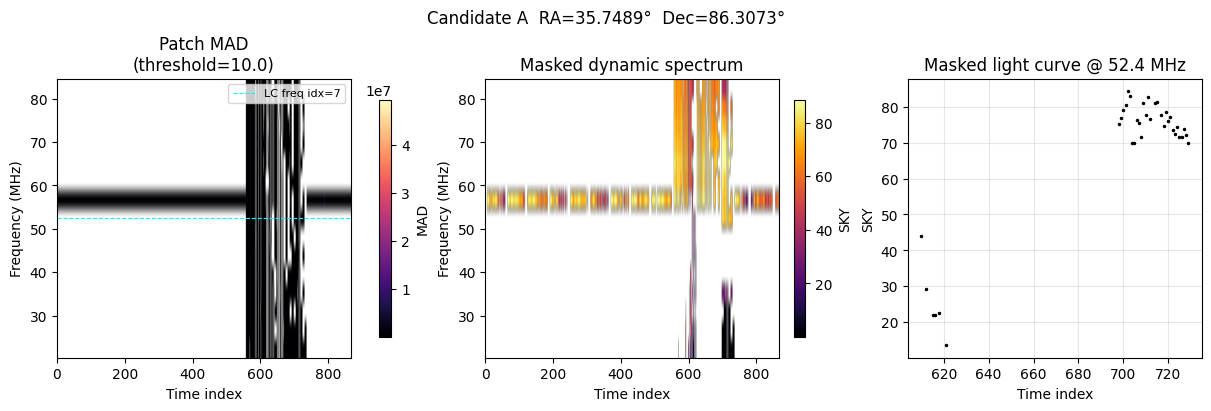

Extracting tracked pixels...
[########################################] | 100% Completed | 18.16 s
Extracting tracked pixels...
[########################################] | 100% Completed | 2.00 s


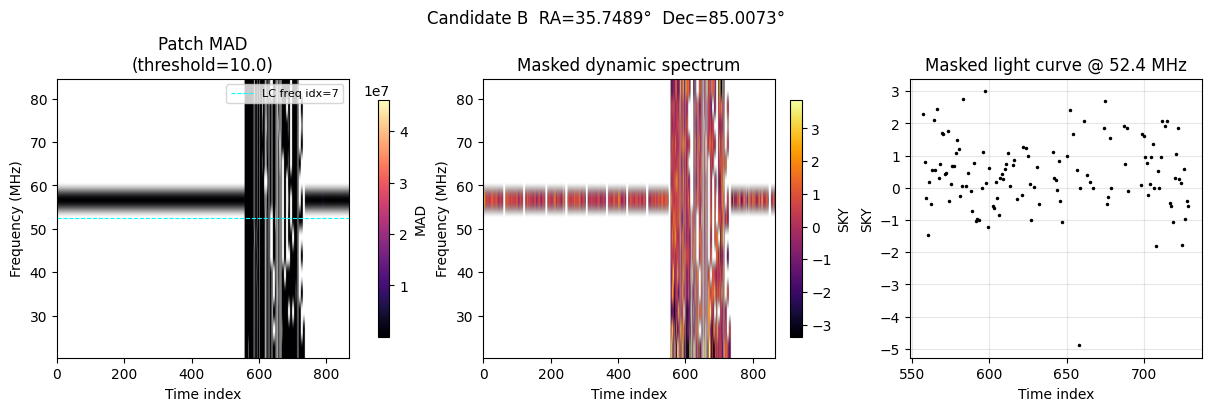

Extracting tracked pixels...
[########################################] | 100% Completed | 18.23 s
Extracting tracked pixels...
[########################################] | 100% Completed | 2.00 s


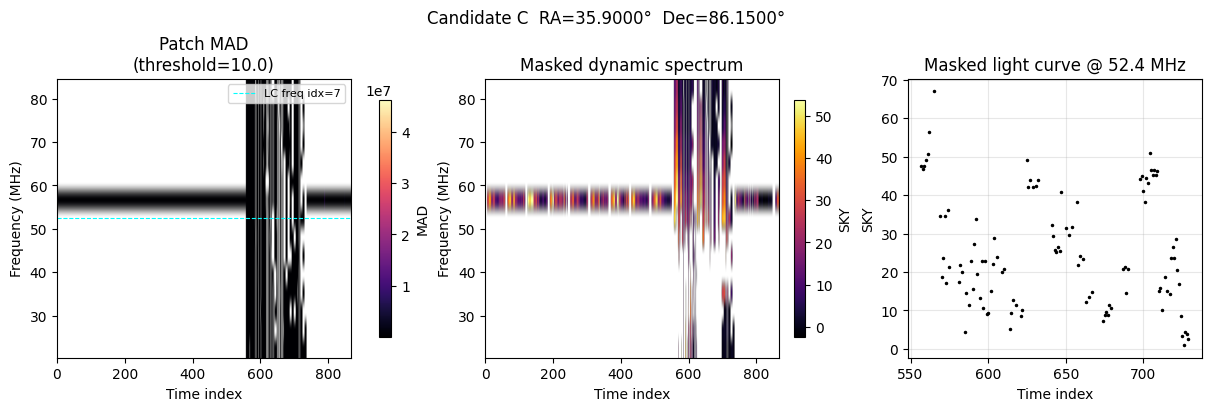

In [7]:
def _time_labels(time_coord: xr.DataArray) -> np.ndarray:
    return np.arange(time_coord.size)


def _freq_labels_mhz(freq_coord: xr.DataArray) -> np.ndarray:
    return freq_coord.values / 1e6


def plot_masked_review(
    result,
    src: dict,
    *,
    lc_freq_idx: int = LC_FREQ_IDX,
    figsize: tuple[float, float] = (12, 4),
):
    """Plot MAD map, masked dynamic spectrum, and masked light curve."""
    dynspec = result.dynamic_spectrum()
    lc = result.light_curve(freq_idx=lc_freq_idx)

    time_axis = _time_labels(dynspec.coords["time"])
    freq_mhz = _freq_labels_mhz(dynspec.coords["frequency"])

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    mad_map = result.stat_map.values
    im0 = axes[0].imshow(
        mad_map.T,
        aspect="auto",
        origin="lower",
        extent=[time_axis[0], time_axis[-1], freq_mhz[0], freq_mhz[-1]],
        cmap="magma",
    )
    axes[0].axhline(
        freq_mhz[lc_freq_idx],
        color="cyan",
        ls="--",
        lw=0.8,
        label=f"LC freq idx={lc_freq_idx}",
    )
    axes[0].set_xlabel("Time index")
    axes[0].set_ylabel("Frequency (MHz)")
    axes[0].set_title(f"Patch MAD\n(threshold={MAD_THRESHOLD})")
    fig.colorbar(im0, ax=axes[0], label="MAD", shrink=0.85)
    axes[0].legend(loc="upper right", fontsize=8)

    data = dynspec.values
    finite = data[np.isfinite(data)]
    if finite.size:
        vmin, vmax = np.percentile(finite, [2, 98])
    else:
        vmin, vmax = None, None

    im1 = axes[1].imshow(
        data.T,
        aspect="auto",
        origin="lower",
        extent=[time_axis[0], time_axis[-1], freq_mhz[0], freq_mhz[-1]],
        cmap="inferno",
        vmin=vmin,
        vmax=vmax,
    )
    axes[1].set_xlabel("Time index")
    axes[1].set_ylabel("Frequency (MHz)")
    axes[1].set_title("Masked dynamic spectrum")
    fig.colorbar(im1, ax=axes[1], label="SKY", shrink=0.85)

    lc_vals = lc.values
    axes[2].plot(time_axis, lc_vals, "k.", ms=3)
    axes[2].set_xlabel("Time index")
    axes[2].set_ylabel("SKY")
    axes[2].set_title(f"Masked light curve @ {freq_mhz[lc_freq_idx]:.1f} MHz")
    axes[2].grid(alpha=0.3)

    fig.suptitle(
        f"{src['name']}  RA={src['ra']:.4f}°  Dec={src['dec']:.4f}°",
        fontsize=12,
    )
    return fig


for src, result in zip(sources, results, strict=True):
    plot_masked_review(result, src)
    plt.show()

## 5. Interactive SkyWidget review

Use the controls to:

- **Source** — switch between candidates in the list
- **Time index / Frequency index** — pick the sky slice (also shown on the MAD
  and dynamic-spectrum plots as vertical/horizontal guides)
- **Light-curve frequency index** — change which channel the 1D plot uses

The sky view recenters on the selected source and updates the displayed
time/frequency slice. Cross-check the plots before trusting a slice.

In [8]:
sky_widget = SkyWidget()
sky_widget.set_dataset(ds, max_size=ds.sizes["l"] // 2)
sky_widget.background_survey = "DSS"
sky_widget.colormap = "inferno"
sky_widget.stretch = "sqrt"
sky_widget.invert_horizontal_pan = True

# set_dataset() starts at (0, 0), which is all-NaN for this observation
sky_widget.update_slice(time_idx=DEFAULT_TIME_IDX, freq_idx=DEFAULT_FREQ_IDX)
sky_widget.auto_scale(percentile_low=2, percentile_high=98)

plot_output = widgets.Output()
status_output = widgets.Output()

source_dropdown = widgets.Dropdown(
    options=[(src["name"], idx) for idx, src in enumerate(sources)],
    description="Source",
    style={"description_width": "initial"},
)
time_slider = widgets.IntSlider(
    value=DEFAULT_TIME_IDX,
    min=0,
    max=n_times - 1,
    description="Time idx",
    continuous_update=False,
)
freq_slider = widgets.IntSlider(
    value=DEFAULT_FREQ_IDX,
    min=0,
    max=n_freqs - 1,
    description="Freq idx",
    continuous_update=False,
)
lc_freq_slider = widgets.IntSlider(
    value=LC_FREQ_IDX,
    min=0,
    max=n_freqs - 1,
    description="LC freq idx",
    continuous_update=False,
)
fov_slider = widgets.FloatSlider(
    value=8.0,
    min=1.0,
    max=45.0,
    step=0.5,
    description="FOV (deg)",
    continuous_update=False,
)


def refresh_review(_=None):
    source_idx = source_dropdown.value
    time_idx = time_slider.value
    freq_idx = freq_slider.value
    lc_freq_idx = lc_freq_slider.value
    fov_deg = fov_slider.value

    src = sources[source_idx]
    result = results[source_idx]
    coord = SkyCoord(ra=src["ra"] * u.deg, dec=src["dec"] * u.deg, frame="fk5")
    freq_mhz = float(ds.frequency.values[freq_idx]) / 1e6

    sky_widget.update_slice(time_idx=time_idx, freq_idx=freq_idx)
    sky_widget.auto_scale(percentile_low=2, percentile_high=98)
    sky_widget.goto(coord, fov=fov_deg * u.deg)

    with plot_output:
        plot_output.clear_output(wait=True)
        fig = plot_masked_review(result, src, lc_freq_idx=lc_freq_idx)
        for ax in fig.axes[:2]:
            ax.axvline(time_idx, color="white", ls="--", lw=0.8, alpha=0.8)
            ax.axhline(freq_mhz, color="white", ls="--", lw=0.8, alpha=0.8)
        fig.axes[2].axvline(time_idx, color="red", ls="--", lw=0.8, alpha=0.8)
        display(fig)
        plt.close(fig)

    selected = bool(result.selection.isel(time=time_idx, frequency=freq_idx).values)
    mad_val = float(result.stat_map.isel(time=time_idx, frequency=freq_idx).values)
    with status_output:
        status_output.clear_output(wait=True)
        print(
            f"{src['name']} | time={time_idx}, freq={freq_idx} ({freq_mhz:.1f} MHz)"
            f" | MAD={mad_val:.3g} | mask={'PASS' if selected else 'REJECT'}"
        )


controls = widgets.VBox(
    [
        widgets.HBox([source_dropdown, time_slider, freq_slider]),
        widgets.HBox([lc_freq_slider, fov_slider]),
        status_output,
    ]
)

for widget in (source_dropdown, time_slider, freq_slider, lc_freq_slider, fov_slider):
    widget.observe(refresh_review, names="value")

refresh_review()
display(widgets.VBox([controls, plot_output, sky_widget]))

[######################################  ] | 95% Completed | 17.31 s

## Notes

- **MAD threshold:** Lower values are stricter and reject more cells. Inspect
  the MAD map (left panel) when tuning `MAD_THRESHOLD`.
- **Patch radius:** Larger patches include more surrounding emission and can
  raise the MAD when nearby bright structure is present.
- **First run:** Patch extraction over 867 time steps takes ~15–20 s per source
  on this dataset; results are cached in the `results` list for reuse.
- **SkyWidget:** Early time indices in this dataset are all-NaN; the notebook
  uses `find_valid_frame()` for the initial slice. If the radio overlay
  disappears, move the time slider to a slice with finite SKY data.
- **SkyWidget:** Pan and zoom on the sphere independently; use the sliders to
  change the underlying time/frequency slice shown in the overlay.